In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits
from sklearn import datasets
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

from pytorch_model_summary import summary

In [2]:
class Digits(Dataset):
    """Scikit-Learn Digits dataset."""

    def __init__(self, mode='train', transforms=None):
        digits = load_digits()
        if mode == 'train':
            self.data = digits.data[:1000].astype(np.float32)
        elif mode == 'val':
            self.data = digits.data[1000:1350].astype(np.float32)
        else:
            self.data = digits.data[1350:].astype(np.float32)

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

In [3]:
class CausalConv1d(nn.Module):
    """
    A causal 1D convolution.
    """

    def __init__(self, in_channels, out_channels, kernel_size, dilation, A=False, **kwargs):
        super(CausalConv1d, self).__init__()

        # attributes:
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.A = A
        
        self.padding = (kernel_size - 1) * dilation + A * 1

        # module:
        self.conv1d = torch.nn.Conv1d(in_channels, out_channels,
                                      kernel_size, stride=1,
                                      padding=0,
                                      dilation=dilation,
                                      **kwargs)

    def forward(self, x):
        x = torch.nn.functional.pad(x, (self.padding, 0))
        conv1d_out = self.conv1d(x)
        if self.A:
            return conv1d_out[:, :, : -1]
        else:
            return conv1d_out

In [4]:
EPS = 1.e-5

def log_categorical(x, p, num_classes=256, reduction=None, dim=None):
    x_one_hot = F.one_hot(x.long(), num_classes=num_classes)
    log_p = x_one_hot * torch.log(torch.clamp(p, EPS, 1. - EPS))
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p

In [5]:
class ARM(nn.Module):
    def __init__(self, net, D=2, num_vals=256):
        super(ARM, self).__init__()

        self.net = net
        self.num_vals = num_vals
        self.D = D

    def f(self, x):
        h = self.net(x.unsqueeze(1))

        h = h.permute(0, 2, 1)
        p = torch.softmax(h, 2)
        return p
        
    def forward(self, x, reduction='avg'):
        if reduction == 'avg':
            return -(self.log_prob(x).mean())
        elif reduction == 'sum':
            return -(self.log_prob(x).sum())
        else:
            raise ValueError('reduction could be either `avg` or `sum`.')

    def log_prob(self, x):
        mu_d = self.f(x)
        log_p = log_categorical(x, mu_d, num_classes=self.num_vals, reduction='sum', dim=-1).sum(-1)
        
        return log_p

    def sample(self, batch_size):
        x_new = torch.zeros((batch_size, self.D))

        for d in range(self.D):
            p = self.f(x_new)
            x_new_d = torch.multinomial(p[:, d, :], num_samples=1)
            x_new[:, d] = x_new_d[:,0]

        return x_new

In [6]:
def evaluation(test_loader, name=None, model_best=None, epoch=None):
    # EVALUATION
    if model_best is None:
        if name is None:
            raise ValueError('Either pass model_best or a model name to load.')
        model_best = torch.load(name + '.model', map_location='cpu', weights_only=False)

    model_best.eval()
    loss = 0.
    N = 0.
    for indx_batch, test_batch in enumerate(test_loader):
        loss_t = model_best.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N

    if epoch is None:
        print(f'FINAL LOSS: nll={loss}')
    else:
        print(f'Epoch: {epoch}, val nll={loss}')

    return loss


def samples_real(test_loader):
    # REAL-------
    num_x = 4
    num_y = 4
    x = next(iter(test_loader)).detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()


def samples_generated(model, data_loader, extra_name=''):
    del data_loader, extra_name
    model.eval()

    num_x = 4
    num_y = 4
    x = model.sample(num_x * num_y)
    x = x.detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()


def plot_curve(nll_val):
    plt.plot(np.arange(len(nll_val)), nll_val, linewidth='3')
    plt.xlabel('epochs')
    plt.ylabel('nll')
    plt.show()

In [7]:
def training(name=None, max_patience=20, num_epochs=1000, model=None, optimizer=None, training_loader=None, val_loader=None):
    nll_val = []
    best_nll = 1000.
    patience = 0

    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            if hasattr(model, 'dequantization'):
                if model.dequantization:
                    batch = batch + torch.rand(batch.shape)
            loss = model.forward(batch)

            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Validation
        loss_val = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_val)

        if e == 0:
            best_nll = loss_val
        else:
            if loss_val < best_nll:
                best_nll = loss_val
                patience = 0
                samples_generated(model, val_loader)
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    nll_val = np.asarray(nll_val)

    return nll_val

In [8]:
train_data = Digits(mode='train')
val_data = Digits(mode='val')
test_data = Digits(mode='test')

training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


In [9]:
D = 64   # input dimension
M = 256  # the number of neurons in scale (s) and translation (t) nets

lr = 1e-3 # learning rate
num_epochs = 1000 # max. number of epochs
max_patience = 20 # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

In [10]:
likelihood_type = 'categorical'

num_vals = 17

kernel = 7

net = nn.Sequential(
    CausalConv1d(in_channels=1, out_channels=M, dilation=1, kernel_size=kernel, A=True, bias=True),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=M, out_channels=M, dilation=1, kernel_size=kernel, A=False, bias=True),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=M, out_channels=M, dilation=1, kernel_size=kernel, A=False, bias=True),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=M, out_channels=num_vals, dilation=1, kernel_size=kernel, A=False, bias=True))

model = ARM(net, D=D, num_vals=num_vals)

# Print the summary (like in Keras)
print(summary(model, torch.zeros(1, 64), show_input=False, show_hierarchical=False))

-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
    CausalConv1d-1        [1, 256, 64]           2,048           2,048
       LeakyReLU-2        [1, 256, 64]               0               0
    CausalConv1d-3        [1, 256, 64]         459,008         459,008
       LeakyReLU-4        [1, 256, 64]               0               0
    CausalConv1d-5        [1, 256, 64]         459,008         459,008
       LeakyReLU-6        [1, 256, 64]               0               0
    CausalConv1d-7         [1, 17, 64]          30,481          30,481
Total params: 950,545
Trainable params: 950,545
Non-trainable params: 0
-----------------------------------------------------------------------


In [11]:
# OPTIMIZER
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad == True], lr=lr)

Epoch: 0, val nll=119.09930245535715
Epoch: 1, val nll=112.1832666015625


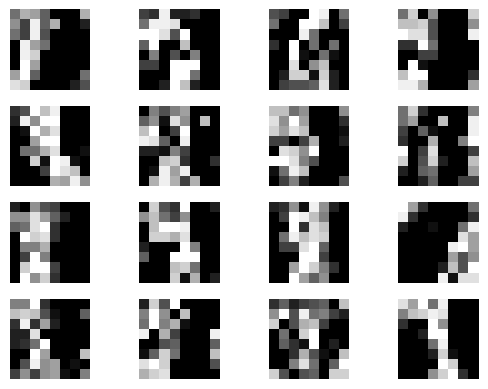

Epoch: 2, val nll=109.26721470424107


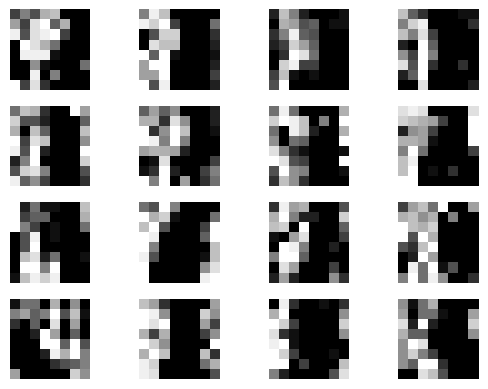

Epoch: 3, val nll=107.165859375


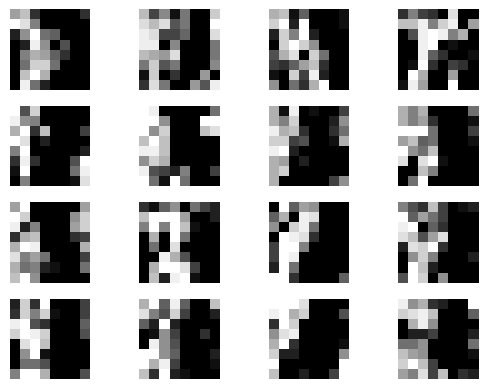

Epoch: 4, val nll=104.5024462890625


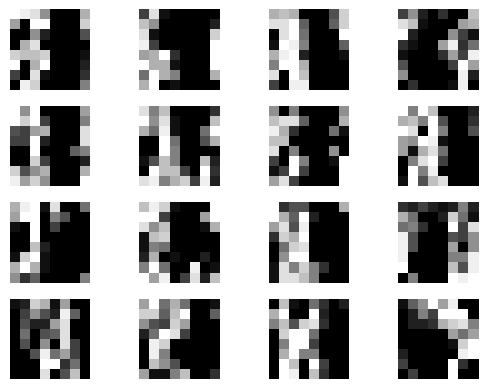

Epoch: 5, val nll=101.8625146484375


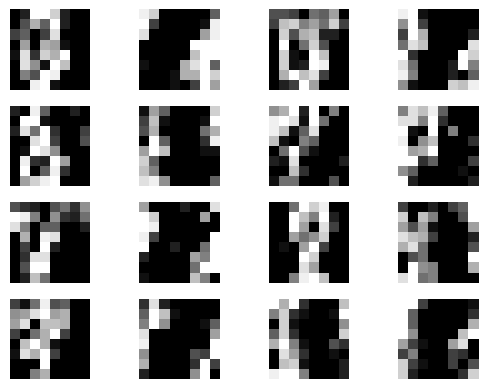

Epoch: 6, val nll=99.57985630580357


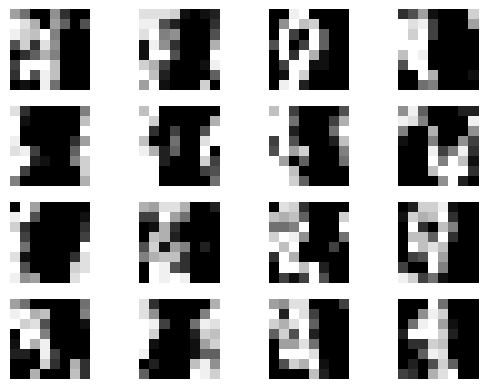

Epoch: 7, val nll=97.72640973772322


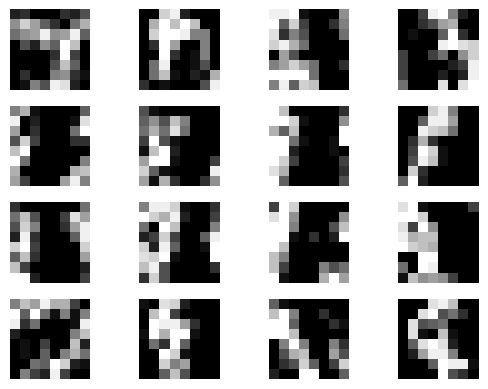

Epoch: 8, val nll=96.41660784040178


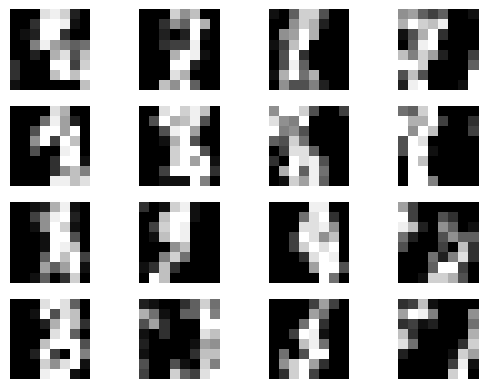

Epoch: 9, val nll=95.04865164620536


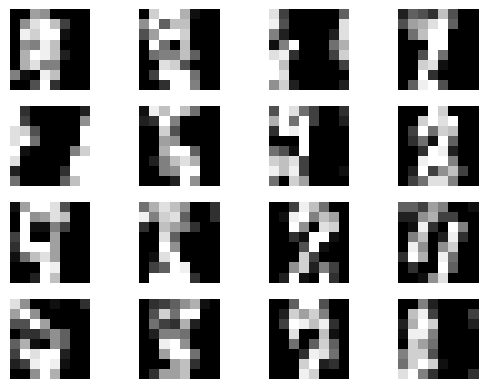

Epoch: 10, val nll=93.916640625


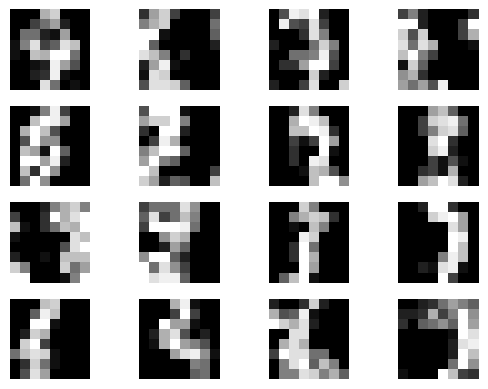

Epoch: 11, val nll=93.38435407366072


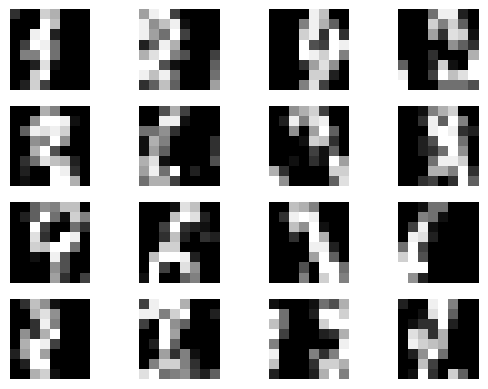

Epoch: 12, val nll=93.05520228794643


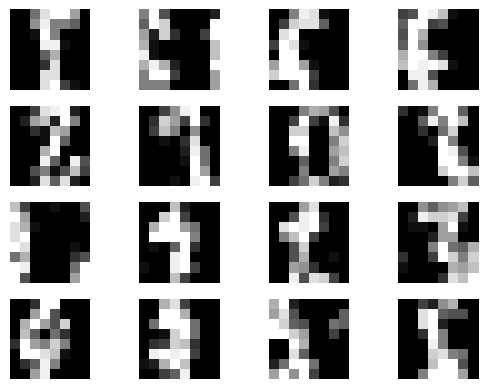

Epoch: 13, val nll=92.48465680803571


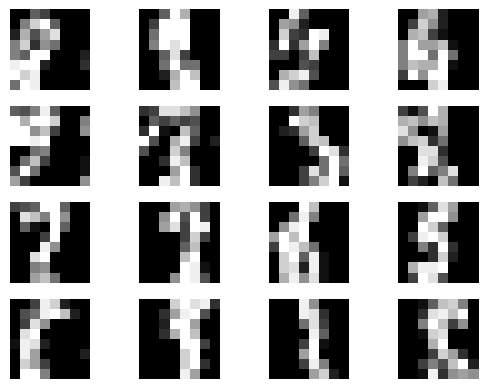

Epoch: 14, val nll=92.14678362165179


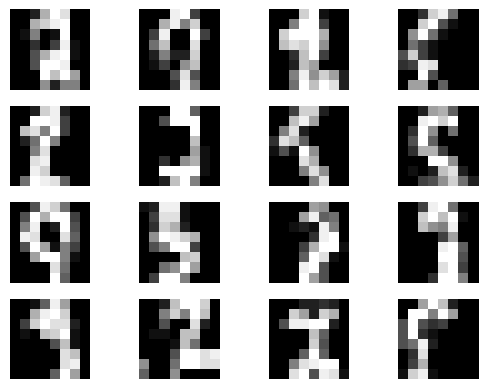

Epoch: 15, val nll=91.74431710379464


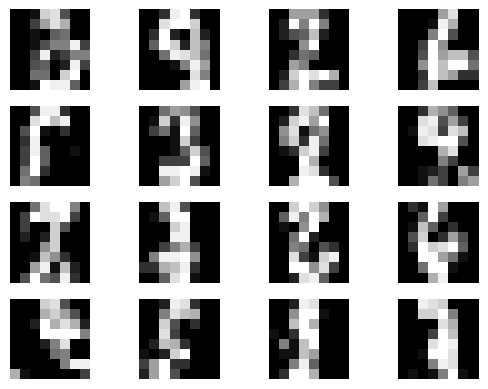

Epoch: 16, val nll=91.573857421875


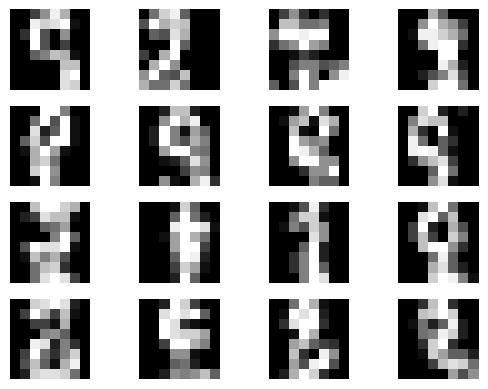

Epoch: 17, val nll=91.17433244977678


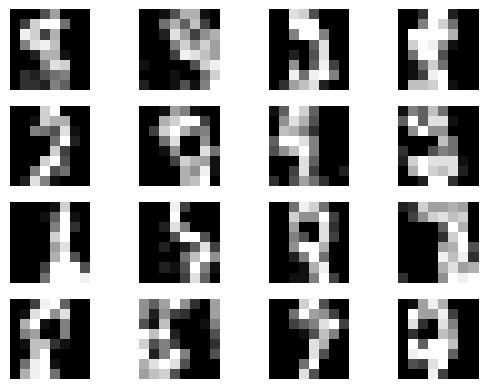

Epoch: 18, val nll=90.96843819754464


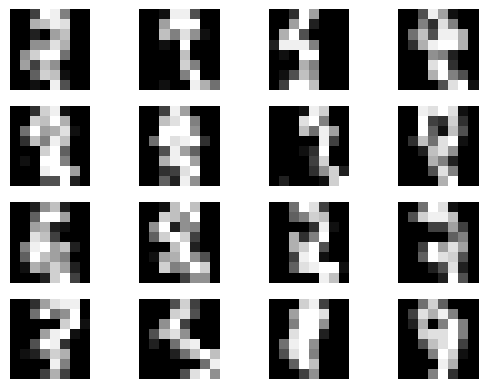

Epoch: 19, val nll=90.81260811941964


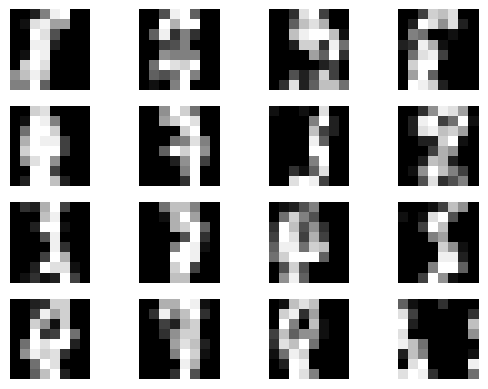

Epoch: 20, val nll=90.58261858258929


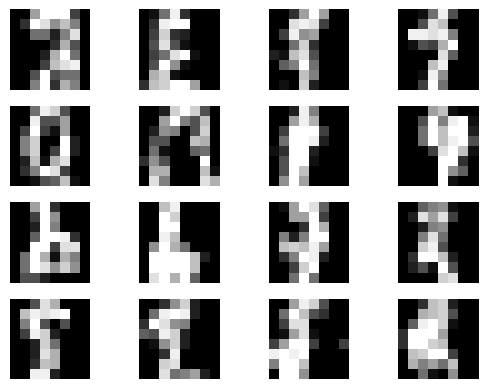

Epoch: 21, val nll=90.26726911272321


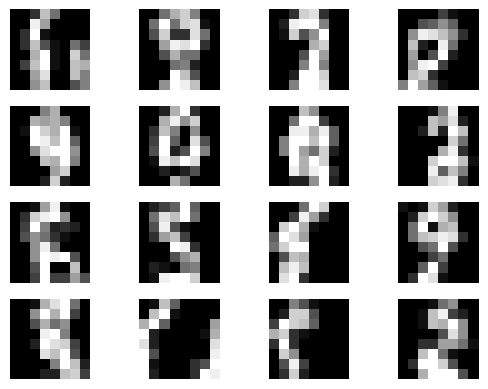

Epoch: 22, val nll=90.46276297433036
Epoch: 23, val nll=90.10690150669643


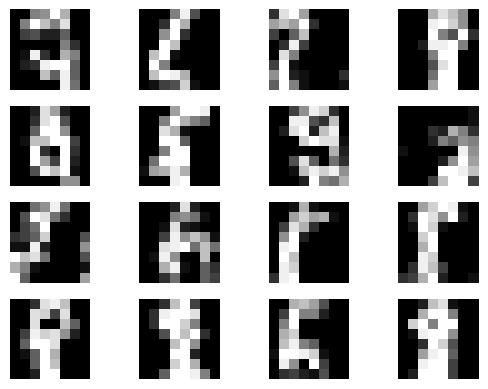

Epoch: 24, val nll=90.25806082589285
Epoch: 25, val nll=90.00970982142857


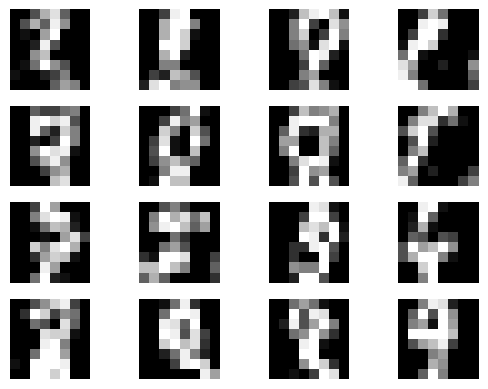

Epoch: 26, val nll=89.3459814453125


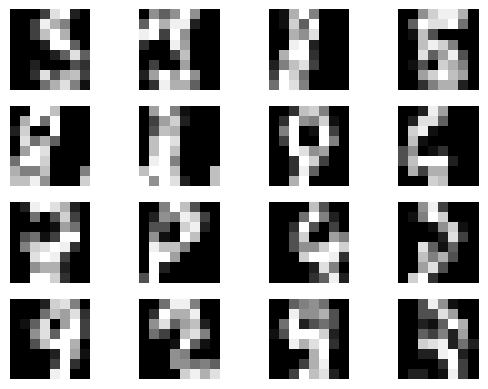

Epoch: 27, val nll=89.8706298828125
Epoch: 28, val nll=89.86879952566964
Epoch: 29, val nll=89.47878976004465
Epoch: 30, val nll=89.31078822544643


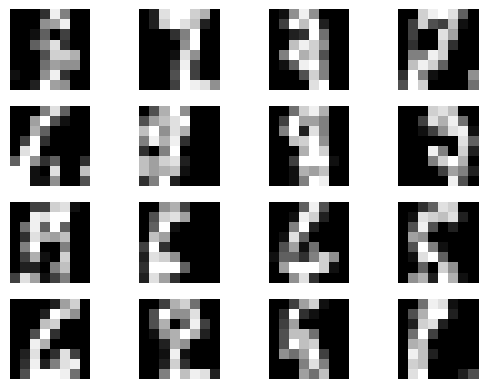

Epoch: 31, val nll=89.2862060546875


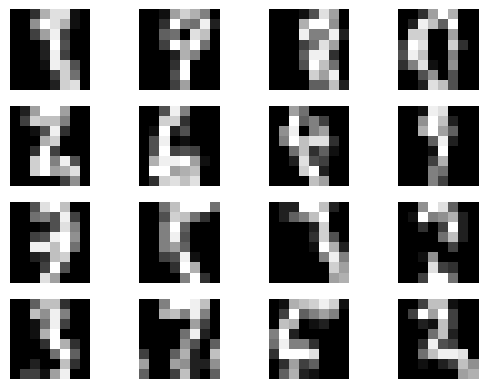

Epoch: 32, val nll=89.39133091517857
Epoch: 33, val nll=89.06398716517857


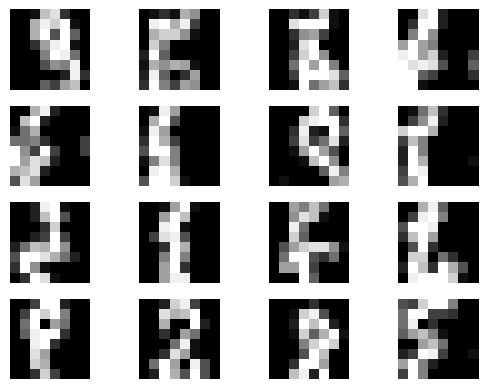

Epoch: 34, val nll=89.40660016741072
Epoch: 35, val nll=89.11353376116071
Epoch: 36, val nll=89.17778599330357
Epoch: 37, val nll=88.86248883928572


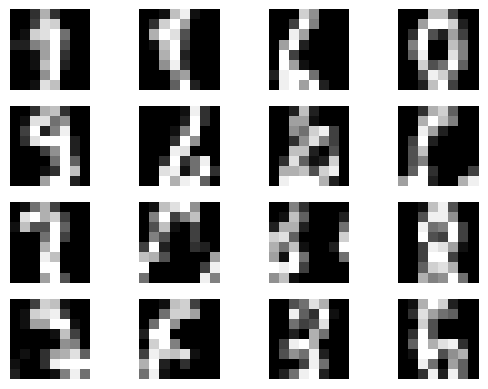

Epoch: 38, val nll=89.16405831473215
Epoch: 39, val nll=89.19403041294643
Epoch: 40, val nll=89.20543178013394
Epoch: 41, val nll=89.13350306919642
Epoch: 42, val nll=89.13599260602679
Epoch: 43, val nll=89.0277490234375
Epoch: 44, val nll=88.8320361328125


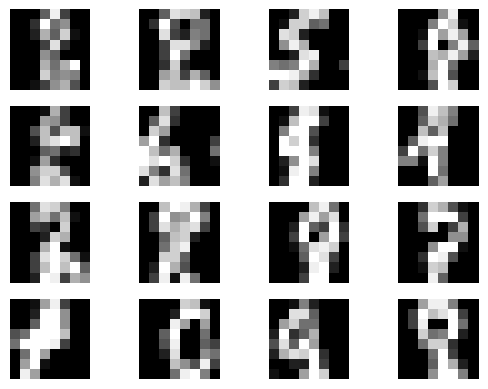

Epoch: 45, val nll=88.94118233816964
Epoch: 46, val nll=89.09122628348214
Epoch: 47, val nll=89.35283133370535
Epoch: 48, val nll=89.67561314174107
Epoch: 49, val nll=89.21549107142857
Epoch: 50, val nll=89.540458984375
Epoch: 51, val nll=89.70346609933036
Epoch: 52, val nll=89.39538155691965
Epoch: 53, val nll=89.70504464285715
Epoch: 54, val nll=89.99180036272321
Epoch: 55, val nll=89.54839146205357
Epoch: 56, val nll=89.70176060267858
Epoch: 57, val nll=90.1718115234375
Epoch: 58, val nll=90.12799874441964
Epoch: 59, val nll=89.94525599888392
Epoch: 60, val nll=90.56393415178572
Epoch: 61, val nll=90.621806640625
Epoch: 62, val nll=90.7098388671875
Epoch: 63, val nll=90.694580078125
Epoch: 64, val nll=90.83924176897321
Epoch: 65, val nll=91.01781389508929


In [12]:
# Training procedure
nll_val = training(name=None, max_patience=max_patience, num_epochs=num_epochs, model=model, optimizer=optimizer,
                       training_loader=training_loader, val_loader=val_loader)

FINAL LOSS: nll=88.33546560402685
Test loss: 88.33546560402685


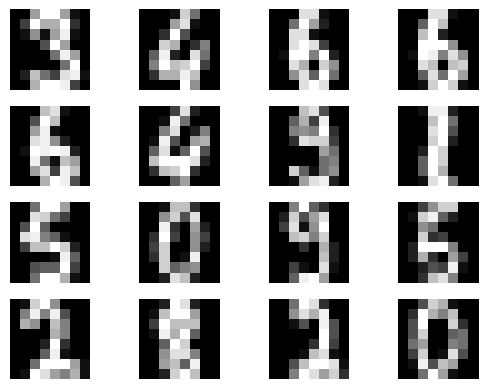

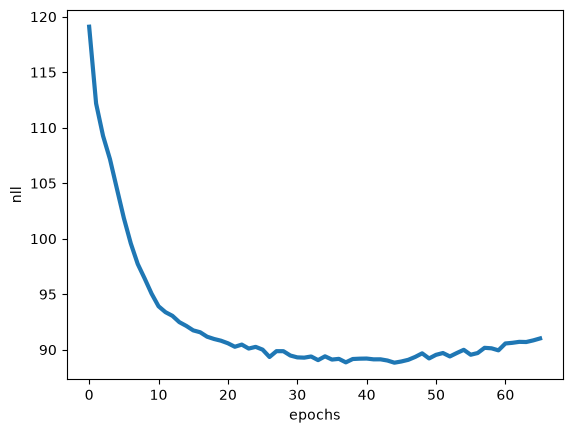

In [13]:
# Evaluate and display results without saving anything to disk
test_loss = evaluation(model_best=model, test_loader=test_loader)
print(f'Test loss: {test_loss}')

samples_real(test_loader)
plot_curve(nll_val)